# 🚀 SpaceX Launch Analysis — Lesson 3: Data Cleaning & Feature Engineering

**Goal:** Fix messy data and create new columns that make our analysis more powerful.

---

## Why this matters

Real-world data is never clean. You'll spend 60–80% of your time as a data analyst on this step — not on charts or models. The quality of your output is only as good as the quality of your input.

**Data cleaning** = fixing what's broken (nulls, wrong types, bad values)

**Feature engineering** = creating new columns from existing data to unlock deeper insights

In this lesson we'll:
1. Handle the 24 missing `landing_success` values
2. Fix the `date` column type
3. Engineer 4 new columns: `era`, `decade`, `payload_category`, `landing_attempted`
4. Validate our cleaned dataset
5. Save the clean version for Lesson 4

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/spacex_launches.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nMissing values:')
print(df.isnull().sum())

Loaded: 135 rows × 11 columns

Missing values:
flight_number       0
name                0
date                0
rocket              0
launchpad           0
success             0
payload_kg          0
orbit               0
landing_success    24
reused              0
customer_type       0
dtype: int64


---

## Step 1: Fix the `date` column

Right now `date` is dtype `object` (a string). We need it as a proper datetime so we can extract year, month, etc.

This is the same thing we did in Lessons 1 & 2, but now we'll also pull out multiple time components at once.

In [2]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract time components — all at once
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')  # 'Jan', 'Feb', etc.

print('Date columns added:')
print(df[['date', 'year', 'month', 'month_name']].head(8))

Date columns added:
        date  year  month month_name
0 2006-03-24  2006      3        Mar
1 2007-03-21  2007      3        Mar
2 2008-08-02  2008      8        Aug
3 2008-09-28  2008      9        Sep
4 2009-07-13  2009      7        Jul
5 2010-06-04  2010      6        Jun
6 2012-05-22  2012      5        May
7 2012-10-08  2012     10        Oct


---

## Step 2: Handle missing `landing_success` values

We have 24 nulls in `landing_success`. Before we fix them, we need to understand **why** they're null — blindly filling them in could corrupt our analysis.

**Rule of data cleaning: always understand the reason for missing data before deciding how to handle it.**

In [3]:
# Who are the rows with missing landing_success?
missing_landing = df[df['landing_success'].isnull()]
print(f'Rows with null landing_success: {len(missing_landing)}')
print()
print('Rocket breakdown:')
print(missing_landing['rocket'].value_counts())
print()
print('Year range:')
print(missing_landing['year'].value_counts().sort_index())

Rows with null landing_success: 24

Rocket breakdown:
rocket
Falcon 9 v1.1    11
Falcon 1          5
Falcon 9 v1.0     4
Falcon 9 FT       4
Name: count, dtype: int64

Year range:
year
2006    1
2007    1
2008    2
2009    1
2010    1
2012    2
2013    3
2014    6
2015    3
2016    1
2017    3
Name: count, dtype: int64


**🧠 What we're seeing:**
The nulls are almost entirely early Falcon 1 and Falcon 9 v1.0/v1.1 launches — before SpaceX even attempted booster landings. A null here doesn't mean "unknown" — it means "landing was never attempted."

So instead of filling with True or False (both would be wrong), we create a separate column that captures this distinction clearly.

In [4]:
# Create a new column: was a landing even attempted?
df['landing_attempted'] = df['landing_success'].notnull()
# notnull() returns True if value exists, False if null

# Now fill the nulls in landing_success with False
# (no attempt = not a success)
df['landing_success'] = df['landing_success'].fillna(False)

# Convert landing_success to bool (it may have loaded as object)
df['landing_success'] = df['landing_success'].astype(bool)

print('landing_attempted breakdown:')
print(df['landing_attempted'].value_counts())
print()
print('landing_success breakdown (after fill):')
print(df['landing_success'].value_counts())
print()
print('Null check — should be 0:')
print(df['landing_success'].isnull().sum())

landing_attempted breakdown:
landing_attempted
True     111
False     24
Name: count, dtype: int64

landing_success breakdown (after fill):
landing_success
True     95
False    40
Name: count, dtype: int64

Null check — should be 0:
0


/sessions/gallant-gracious-carson/tmp/ipykernel_8/2175646458.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['landing_success'] = df['landing_success'].fillna(False)


---

## Step 3: Feature Engineering — `era`

SpaceX's history has clear phases. Creating an `era` column lets us group and compare these phases directly.

We'll use `pd.cut()` — it bins a continuous value (year) into labeled categories.

In [5]:
# Define the eras based on SpaceX's actual history
era_bins   = [2005, 2009, 2015, 2018, 2020, 2026]
era_labels = ['Falcon 1 Era', 'Early F9', 'F9 Reuse Begins', 'Block 5 Dominance', 'Starlink Scale-Up']

df['era'] = pd.cut(
    df['year'],
    bins=era_bins,
    labels=era_labels,
    right=True   # bins are (left, right] — right edge is included
)

print('Launches per era:')
print(df['era'].value_counts().sort_index())

Launches per era:
era
Falcon 1 Era          5
Early F9             19
F9 Reuse Begins      45
Block 5 Dominance    31
Starlink Scale-Up    35
Name: count, dtype: int64


---

## Step 4: Feature Engineering — `payload_category`

Payload mass ranges from 0 to 18,500 kg. Binning it into categories makes it easier to compare and visualize.

This is a judgment call — you decide what the bins mean. Document your reasoning.

In [6]:
payload_bins   = [-1, 0, 1000, 5000, 10000, 20000]
payload_labels = ['Unknown/Classified', 'Light (<1t)', 'Medium (1–5t)', 'Heavy (5–10t)', 'Super Heavy (>10t)']

df['payload_category'] = pd.cut(
    df['payload_kg'],
    bins=payload_bins,
    labels=payload_labels
)

print('Launches per payload category:')
print(df['payload_category'].value_counts())

Launches per payload category:
payload_category
Medium (1–5t)         53
Super Heavy (>10t)    33
Heavy (5–10t)         24
Light (<1t)           15
Unknown/Classified    10
Name: count, dtype: int64


---

## Step 5: Feature Engineering — `booster_flights`

How many times has a booster been flown matters — but our dataset only has `reused` (True/False). We can derive a flight sequence number per launch within each year using `cumcount()`.

In [7]:
# Cumulative launch number per year (resets each year)
# Useful for showing launch cadence within a year
df = df.sort_values('date').reset_index(drop=True)
df['launch_num_in_year'] = df.groupby('year').cumcount() + 1
# cumcount() assigns 0,1,2,3... within each group
# +1 makes it 1-indexed

print('Sample — launch sequence within each year:')
print(df[['year', 'name', 'launch_num_in_year']].tail(15))

Sample — launch sequence within each year:
     year                            name  launch_num_in_year
120  2022                          Crew-5                   8
121  2022                  Galaxy 31 & 32                   9
122  2022  Hakuto-R M1 / Lunar Flashlight                  10
123  2023                          Crew-6                   1
124  2023                   Transporter-7                   2
125  2023                  Starship IFT-1                   3
126  2023                          Crew-7                   4
127  2023                          CRS-29                   5
128  2023                  Starship IFT-2                   6
129  2024                          Crew-8                   1
130  2024                  Starship IFT-3                   2
131  2024                  Starship IFT-4                   3
132  2024                          Crew-9                   4
133  2024                  Starship IFT-5                   5
134  2024                  

---

## Step 6: Validate the cleaned dataset

Before saving, always do a sanity check. You're verifying:
- No unexpected nulls
- Column types are correct
- New columns look right

In [8]:
print('=== CLEANED DATASET VALIDATION ===')
print(f'Shape: {df.shape}')
print()
print('Null counts:')
print(df.isnull().sum())
print()
print('Column dtypes:')
print(df.dtypes)

=== CLEANED DATASET VALIDATION ===
Shape: (135, 18)

Null counts:
flight_number         0
name                  0
date                  0
rocket                0
launchpad             0
success               0
payload_kg            0
orbit                 0
landing_success       0
reused                0
customer_type         0
year                  0
month                 0
month_name            0
landing_attempted     0
era                   0
payload_category      0
launch_num_in_year    0
dtype: int64

Column dtypes:
flight_number                  int64
name                          object
date                  datetime64[ns]
rocket                        object
launchpad                     object
success                         bool
payload_kg                     int64
orbit                         object
landing_success                 bool
reused                          bool
customer_type                 object
year                           int32
month                        

In [9]:
# Spot check a few rows — look at the new columns
df[['name', 'year', 'rocket', 'era', 'payload_kg', 'payload_category', 
    'landing_attempted', 'landing_success', 'launch_num_in_year']].sample(10, random_state=42)

,name,year,rocket,era,payload_kg,payload_category,landing_attempted,landing_success,launch_num_in_year
98,Starlink 15,2020,Falcon 9 Block 5,Block 5 Dominance,18500,Super Heavy (>10t),True,True,18
67,SSO-A,2018,Falcon 9 Block 5,F9 Reuse Begins,4000,Medium (1–5t),True,True,18
105,Starlink 22,2021,Falcon 9 Block 5,Starlink Scale-Up,18500,Super Heavy (>10t),True,True,6
19,ABS-3A / Eutelsat,2015,Falcon 9 v1.1,Early F9,4159,Medium (1–5t),False,False,3
42,Intelsat 35e,2017,Falcon 9 FT,F9 Reuse Begins,6761,Heavy (5–10t),False,False,10
62,Telstar 19V,2018,Falcon 9 Block 5,F9 Reuse Begins,7075,Heavy (5–10t),True,True,13
12,CRS-3,2014,Falcon 9 v1.1,Early F9,2296,Medium (1–5t),False,False,2
110,Inspiration4,2021,Falcon 9 Block 5,Starlink Scale-Up,12055,Super Heavy (>10t),True,True,11
125,Starship IFT-1,2023,Starship,Starlink Scale-Up,0,Unknown/Classified,True,False,3
128,Starship IFT-2,2023,Starship,Starlink Scale-Up,0,Unknown/Classified,True,False,6


---

## Step 7: Quick analysis with the new features

Let's make sure the new columns actually tell us something useful before we save.

In [10]:
# Success rate by era — this is now possible because of our new column
era_stats = df.groupby('era', observed=True).agg(
    launches=('success', 'count'),
    success_rate=('success', lambda x: round(x.mean() * 100, 1)),
    landing_rate=('landing_success', lambda x: round(x.mean() * 100, 1)),
    reuse_rate=('reused', lambda x: round(x.mean() * 100, 1))
).reset_index()

print('Performance by Era:')
print(era_stats.to_string(index=False))

Performance by Era:
              era  launches  success_rate  landing_rate  reuse_rate
     Falcon 1 Era         5          40.0           0.0         0.0
         Early F9        19          94.7           5.3         0.0
  F9 Reuse Begins        45          97.8          71.1        33.3
Block 5 Dominance        31         100.0          96.8        83.9
Starlink Scale-Up        35          94.3          91.4        82.9


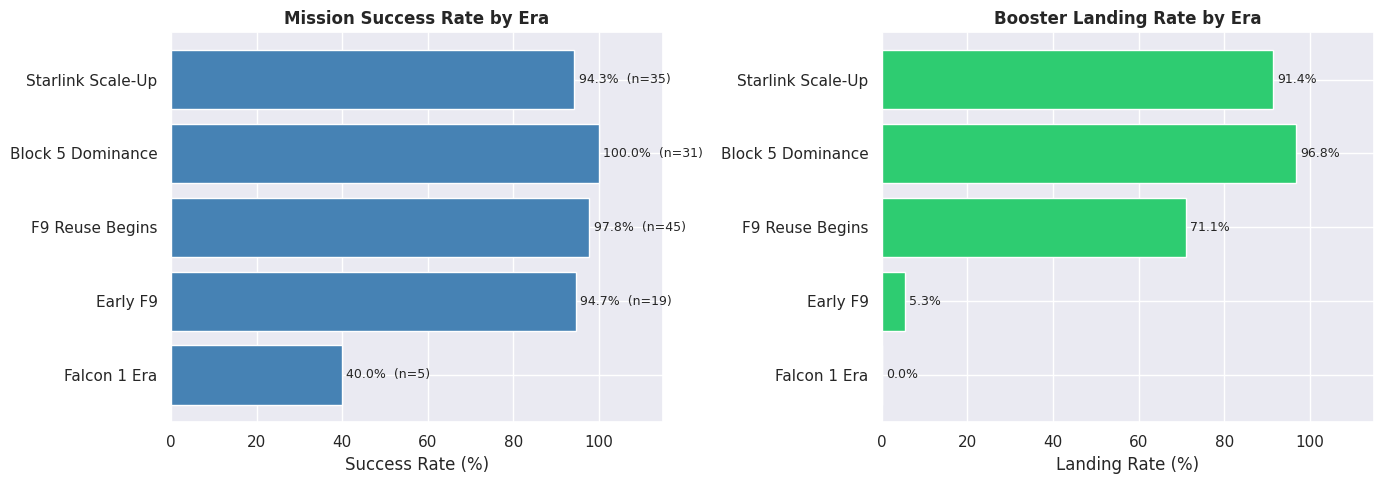

In [11]:
# Visualize: success rate and landing rate by era side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Success rate by era
axes[0].barh(era_stats['era'], era_stats['success_rate'], color='steelblue', edgecolor='white')
axes[0].set_title('Mission Success Rate by Era', fontweight='bold')
axes[0].set_xlabel('Success Rate (%)')
axes[0].set_xlim(0, 115)
for i, (rate, launches) in enumerate(zip(era_stats['success_rate'], era_stats['launches'])):
    axes[0].text(rate + 1, i, f'{rate}%  (n={launches})', va='center', fontsize=9)

# Chart 2: Landing rate by era
axes[1].barh(era_stats['era'], era_stats['landing_rate'], color='#2ecc71', edgecolor='white')
axes[1].set_title('Booster Landing Rate by Era', fontweight='bold')
axes[1].set_xlabel('Landing Rate (%)')
axes[1].set_xlim(0, 115)
for i, rate in enumerate(era_stats['landing_rate']):
    axes[1].text(rate + 1, i, f'{rate}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/era_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 8: Save the cleaned dataset

In [12]:
# Save to a new file — never overwrite your raw data
df.to_csv('../data/spacex_launches_clean.csv', index=False)

print('✅ Clean dataset saved to data/spacex_launches_clean.csv')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   New columns added: era, payload_category, landing_attempted, year, month, month_name, launch_num_in_year')

✅ Clean dataset saved to data/spacex_launches_clean.csv
   Shape: 135 rows × 18 columns
   New columns added: era, payload_category, landing_attempted, year, month, month_name, launch_num_in_year


---

## 🎯 Lesson 3 Summary

| Concept | What you learned |
|---|---|
| `df.isnull().sum()` | Find missing values |
| `df[df['col'].isnull()]` | Filter to just the missing rows |
| `.fillna()` | Fill nulls with a value |
| `.notnull()` | Create a boolean column from null presence |
| `.astype(bool)` | Cast column to a different type |
| `pd.cut()` | Bin a numeric column into labeled categories |
| `dt.year`, `dt.month` | Extract date parts |
| `.groupby().cumcount()` | Running count within a group |
| `lambda x: x.mean()` | Custom aggregation function |
| `df.to_csv()` | Save DataFrame to file |

**Key principle:** Never overwrite raw data. Always save cleaned data to a new file.

---

## ➡️ What's next: Lesson 4 — Deep Dive Analysis

This is the capstone payoff. We'll use the clean dataset to answer the big questions:
- What factors predict launch success?
- How did landing success rate change over time?
- Is there a seasonal pattern in launches?
- What's the reuse impact on success rate?

Then we'll assemble a final summary chart worthy of LinkedIn.